# Resolution-consistent nested white noise

{bdg-primary}`Multiple CUDA GPUs` {bdg-secondary}`32^3 to 256^3` {bdg-success}`evolved to z=0`

`white_noise_nested` hashes each signed integer Fourier coordinate independently.  At a
fixed box size and seed, the 32-, 64-, 128-, and 256-cube runs therefore start with
bitwise-identical shared non-Nyquist modes.  This notebook evolves every realization to
$a=1$ with the same 2LPT and `mesh_halo` N-body pipeline, then compares the final density
fields on a common 32-cube grid.

```{admonition} Committed execution record
:class: note
All outputs and plots on this page are committed in the notebook; hosted documentation
does not execute them.  The first executed output is the environment and configuration
record for the published run.
```


In [1]:
%matplotlib inline
from importlib.metadata import version as distribution_version
from pathlib import Path
import pmpp
import gc
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pmpp.cosmology import boltzmann
from pmpp import Configuration
from pmpp.cosmology import SimpleLCDM
from pmpp.initial_conditions import lpt
from pmpp.initial_conditions import linear_modes, white_noise_nested
from pmpp import MultiGPUConfiguration
from pmpp.nbody import nbody
from pmpp.cic import scatter
from pmpp.distributed import create_compute_mesh

SEED = 7
BOX_SIZE = 100.0
RESOLUTIONS = (32, 64, 128, 256)
CAPACITIES = {
    32: dict(max_ptcl_per_slice=32_768, max_share_ptcl=16_384,
             max_halo_share_ptcl=16_384, max_share_gather_ptcl=16_384),
    64: dict(max_ptcl_per_slice=262_144, max_share_ptcl=65_536,
             max_halo_share_ptcl=65_536, max_share_gather_ptcl=100_000),
    128: dict(max_ptcl_per_slice=1_887_437, max_share_ptcl=500_000,
              max_halo_share_ptcl=500_000, max_share_gather_ptcl=900_000),
    256: dict(max_ptcl_per_slice=10_066_329, max_share_ptcl=1_600_000,
              max_halo_share_ptcl=800_000, max_share_gather_ptcl=1_800_000),
}

gpu_devices = [device for device in jax.devices() if device.platform == "gpu"]
if len(gpu_devices) < 2:
    raise RuntimeError("This precomputed multi-resolution notebook requires at least two visible CUDA devices.")
compute_mesh = create_compute_mesh(gpu_devices)

package_origin = (
    "site-packages"
    if any(part in {"site-packages", "dist-packages"} for part in Path(pmpp.__file__).resolve().parts)
    else "source-tree"
)
execution_record = {
    "pmpp_version": distribution_version("pmpp"),
    "package_origin": package_origin,
    "jax_version": jax.__version__,
    "backend": jax.default_backend(),
    "selected_device_count": len(gpu_devices),
    "visible_device_count": len(jax.devices()),
    "selected_device_models": [device.device_kind for device in gpu_devices],
    "seed": SEED,
    "configuration": {
        "box_size_mpc_h": BOX_SIZE,
        "resolutions": RESOLUTIONS,
        "mesh_ratio": 1,
        "lpt_order": 2,
        "a_start": 1 / 64,
        "a_stop": 1.0,
        "a_nbody_maxstep": 1 / 64,
        "comparison": "shared Fourier modes and block-matched z=0 density",
        "mode": "mesh_halo",
    },
    "capacities": CAPACITIES,
}
print("PM++ DOCUMENTATION EXECUTION RECORD")
for key, value in execution_record.items():
    print(f"{key}: {value}")


PM++ DOCUMENTATION EXECUTION RECORD
pmpp_version: 0.1.6
package_origin: site-packages
jax_version: 0.6.2
backend: gpu
selected_device_count: 2
visible_device_count: 2
selected_device_models: ['NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090']
seed: 7
configuration: {'box_size_mpc_h': 100.0, 'resolutions': (32, 64, 128, 256), 'mesh_ratio': 1, 'lpt_order': 2, 'a_start': 0.015625, 'a_stop': 1.0, 'a_nbody_maxstep': 0.015625, 'comparison': 'shared Fourier modes and block-matched z=0 density', 'mode': 'mesh_halo'}
capacities: {32: {'max_ptcl_per_slice': 32768, 'max_share_ptcl': 16384, 'max_halo_share_ptcl': 16384, 'max_share_gather_ptcl': 16384}, 64: {'max_ptcl_per_slice': 262144, 'max_share_ptcl': 65536, 'max_halo_share_ptcl': 65536, 'max_share_gather_ptcl': 100000}, 128: {'max_ptcl_per_slice': 1887437, 'max_share_ptcl': 500000, 'max_halo_share_ptcl': 500000, 'max_share_gather_ptcl': 900000}, 256: {'max_ptcl_per_slice': 10066329, 'max_share_ptcl': 1600000, 'max_halo_share_ptcl': 800000, 

## One fully compiled simulation per resolution

Each resolution has different static shapes, so each one receives its own configuration
and outer JIT compilation.  The physical box, random seed, cosmology, LPT order, and
scale-factor schedule remain fixed.  Runs execute sequentially so only one large
multi-GPU simulation is resident at a time.


In [2]:
def make_conf(resolution):
    return Configuration(
        ptcl_spacing=BOX_SIZE / resolution,
        ptcl_grid_shape=(resolution,) * 3,
        mesh_shape=1,
        multigpu=MultiGPUConfiguration(compute_mesh=compute_mesh, mode="mesh_halo"),
        **CAPACITIES[resolution],
        lpt_order=2,
        a_start=1 / 64,
        a_stop=1.0,
        a_nbody_maxstep=1 / 64,
        float_dtype=jnp.float32,
    )

def shared_mode_index_map(coarse_size, fine_size):
    coarse_index = np.arange(coarse_size, dtype=np.int32)
    signed = np.where(
        coarse_index < (coarse_size + 1) // 2,
        coarse_index,
        coarse_index - coarse_size,
    )
    if coarse_size % 2 == 0:
        keep = signed != -(coarse_size // 2)
        coarse_index = coarse_index[keep]
        signed = signed[keep]
    fine_index = np.where(signed >= 0, signed, signed + fine_size)
    return coarse_index, fine_index.astype(np.int32)

def compare_shared_modes(coarse_modes, fine_modes, fine_size):
    x_coarse, x_fine = shared_mode_index_map(32, fine_size)
    y_coarse, y_fine = shared_mode_index_map(32, fine_size)
    z_shared = np.arange(32 // 2, dtype=np.int32)  # exclude coarse Nyquist
    shared_coarse = coarse_modes[np.ix_(x_coarse, y_coarse, z_shared)]
    shared_fine = fine_modes[np.ix_(x_fine, y_fine, z_shared)]
    return {
        "shared_mode_count": int(shared_coarse.size),
        "bitwise_equal": bool(np.array_equal(shared_coarse, shared_fine)),
        "maximum_absolute_difference": float(np.max(np.abs(shared_coarse - shared_fine))),
    }

def block_average_to_32(field):
    factor = field.shape[0] // 32
    return field.reshape(32, factor, 32, factor, 32, factor).mean(axis=(1, 3, 5))

downsampled_fields = {}
native_projections = {}
mode_comparisons = {}
timings = {}
coarse_modes = None

for resolution in RESOLUTIONS:
    conf = make_conf(resolution)

    def full_simulation(seed):
        cosmo = boltzmann(SimpleLCDM(conf), conf)
        noise_modes = white_noise_nested(seed, conf)
        modes = linear_modes(noise_modes, cosmo, conf)
        particles = lpt(modes, cosmo, conf)
        particles = nbody(particles, cosmo, conf)
        density = scatter(particles, conf)
        return noise_modes, density

    compiled_simulation = jax.jit(full_simulation)
    started = time.perf_counter()
    noise_modes, density = compiled_simulation(SEED)
    density.block_until_ready()
    timings[resolution] = time.perf_counter() - started

    noise_host = np.asarray(noise_modes)
    density_host = np.asarray(density)
    assert density_host.shape == (resolution,) * 3
    assert np.isfinite(density_host).all()
    np.testing.assert_allclose(density_host.mean(), 1.0, rtol=2e-5, atol=2e-5)
    np.testing.assert_allclose(density_host.sum(), resolution**3, rtol=2e-5)

    if resolution == 32:
        coarse_modes = noise_host.copy()
    mode_comparisons[resolution] = compare_shared_modes(coarse_modes, noise_host, resolution)
    assert mode_comparisons[resolution]["bitwise_equal"]

    downsampled_fields[resolution] = block_average_to_32(density_host)
    native_projections[resolution] = density_host.mean(axis=0)
    print(
        f"{resolution}^3: {timings[resolution]:.1f}s, "
        f"mean={density_host.mean():.8f}, shared modes exact="
        f"{mode_comparisons[resolution]['bitwise_equal']}"
    )

    del conf, compiled_simulation, noise_modes, density, noise_host, density_host
    jax.clear_caches()
    gc.collect()


32^3: 12.9s, mean=1.00000000, shared modes exact=True


64^3: 12.7s, mean=0.99999994, shared modes exact=True


128^3: 13.8s, mean=1.00000000, shared modes exact=True


256^3: 19.0s, mean=0.99999899, shared modes exact=True


## Compare the evolved fields at matched physical cells

Averaging each final density field into $32^3$ physical cells provides arrays with the
same shape and box coordinates.  This is a field-level comparison, not a claim of
elementwise equality: extra small-scale modes change nonlinear evolution, so agreement is
expected to be strongest on large scales and to decrease toward high resolution.


In [3]:
reference = downsampled_fields[32] - 1.0
field_comparison = []
for resolution in RESOLUTIONS:
    candidate = downsampled_fields[resolution] - 1.0
    correlation = float(np.corrcoef(reference.ravel(), candidate.ravel())[0, 1])
    rms_difference = float(np.sqrt(np.mean((candidate - reference) ** 2)))
    field_comparison.append({
        "resolution": resolution,
        "shared_modes_bitwise_equal": mode_comparisons[resolution]["bitwise_equal"],
        "shared_modes_max_abs_difference": mode_comparisons[resolution]["maximum_absolute_difference"],
        "z0_block_field_correlation_with_32": correlation,
        "z0_block_field_rms_difference": rms_difference,
        "compile_and_run_seconds": timings[resolution],
    })

field_comparison


[{'resolution': 32,
  'shared_modes_bitwise_equal': True,
  'shared_modes_max_abs_difference': 0.0,
  'z0_block_field_correlation_with_32': 1.0,
  'z0_block_field_rms_difference': 0.0,
  'compile_and_run_seconds': 12.872900610000215},
 {'resolution': 64,
  'shared_modes_bitwise_equal': True,
  'shared_modes_max_abs_difference': 0.0,
  'z0_block_field_correlation_with_32': 0.7240666470754086,
  'z0_block_field_rms_difference': 1.8662480115890503,
  'compile_and_run_seconds': 12.69675510900197},
 {'resolution': 128,
  'shared_modes_bitwise_equal': True,
  'shared_modes_max_abs_difference': 0.0,
  'z0_block_field_correlation_with_32': 0.5460572075353517,
  'z0_block_field_rms_difference': 2.6360342502593994,
  'compile_and_run_seconds': 13.822361771999567},
 {'resolution': 256,
  'shared_modes_bitwise_equal': True,
  'shared_modes_max_abs_difference': 0.0,
  'z0_block_field_correlation_with_32': 0.4736542592624681,
  'z0_block_field_rms_difference': 2.921444892883301,
  'compile_and_run_s

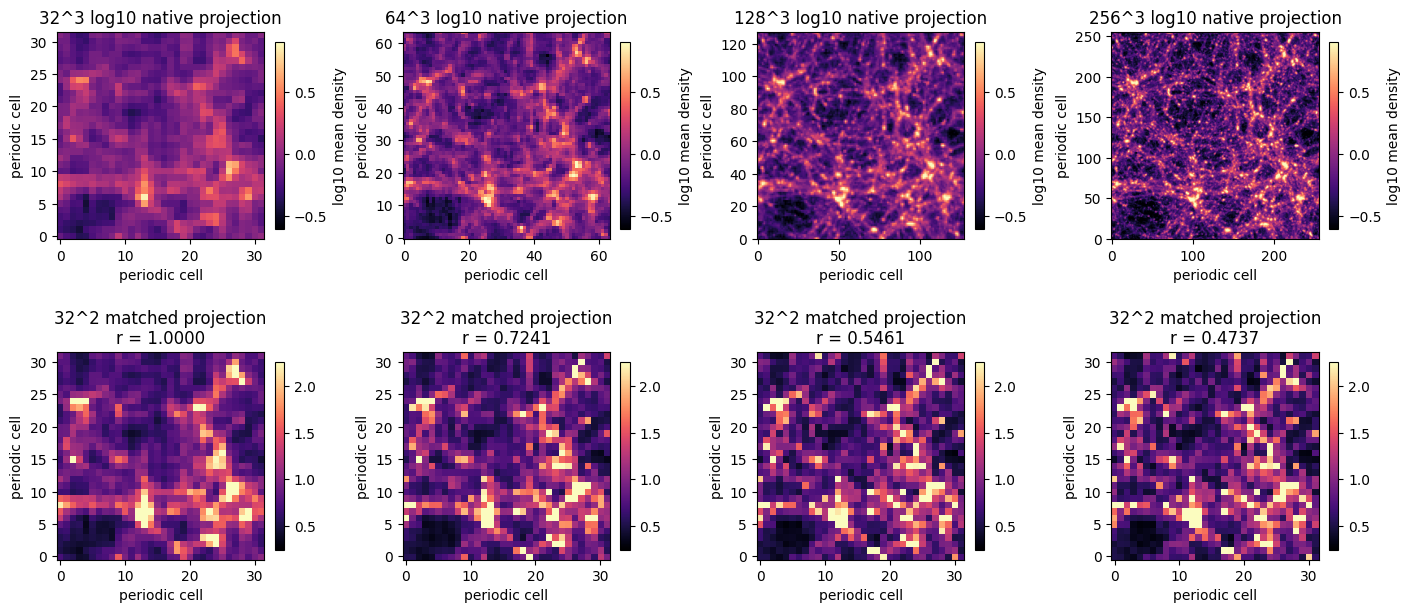

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6.2), constrained_layout=True)
native_log_projections = {
    resolution: np.log10(np.clip(native_projections[resolution], 1e-6, None))
    for resolution in RESOLUTIONS
}
all_native_log_values = np.concatenate([
    native_log_projections[resolution].ravel()
    for resolution in RESOLUTIONS
])
native_vmin, native_vmax = np.percentile(all_native_log_values, (0.5, 99.5))

for column, resolution in enumerate(RESOLUTIONS):
    native_log = native_log_projections[resolution]
    coarse = downsampled_fields[resolution].mean(axis=0)
    corr = field_comparison[column]["z0_block_field_correlation_with_32"]

    image = axes[0, column].imshow(
        native_log,
        origin="lower",
        cmap="magma",
        vmin=native_vmin,
        vmax=native_vmax,
    )
    axes[0, column].set_title(f"{resolution}^3 log10 native projection")
    fig.colorbar(image, ax=axes[0, column], shrink=0.72, label="log10 mean density")

    image = axes[1, column].imshow(coarse, origin="lower", cmap="magma", vmin=0.25, vmax=2.25)
    axes[1, column].set_title(f"32^2 matched projection\nr = {corr:.4f}")
    fig.colorbar(image, ax=axes[1, column], shrink=0.72)

for ax in axes.flat:
    ax.set_xlabel("periodic cell")
    ax.set_ylabel("periodic cell")
plt.show()


The shared non-Nyquist Fourier coefficients are exactly equal at initialization.  The
$z=0$ density fields are deliberately compared after volume-preserving block averaging;
different-resolution real-space arrays should never be asserted elementwise equal.
